# Active Evaluation

In [17]:
import glob
import json
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from plot_style import FONTS, COLOR_PALLETTE


In [18]:
SEVERITY_ORDER = ["BLOCKER", "CRITICAL", "MAJOR", "MINOR", "INFO"]


def load_issues(path: str) -> list[dict]:
    return json.loads(Path(path).read_text())


def issue_key(issue: dict) -> tuple[str, str, str]:
    return (issue["rule_key"], issue["severity"], issue["file_path"])


def compare_to_base(base_issues: list[dict], run_issues: list[dict]):
    base_by_key = {issue_key(i): i for i in base_issues}
    run_by_key = {issue_key(i): i for i in run_issues}
    base_keys, run_keys = set(base_by_key), set(run_by_key)
    return base_keys - run_keys, base_keys & run_keys, run_keys - base_keys, base_by_key, run_by_key


def sum_by_severity(keys: set[tuple], source: dict[tuple, dict], value) -> dict[str, float]:
    totals: dict[str, float] = {}
    for key in keys:
        totals[key[1]] = totals.get(key[1], 0) + value(source[key])
    return totals


def filter_issues(issues: list[dict], locations: set[tuple], mode: str) -> list[dict]:
    hit = lambda i: (i["file_path"], i["line"]) in locations
    return [i for i in issues if hit(i) != (mode == "exclude")]


def per_run_debt(base_issues_all, run_paths, locations, mode):
    base_issues = filter_issues(base_issues_all, locations, mode)
    overall_rows, severity_rows = [], []
    for run_path in run_paths:
        run_issues = filter_issues(load_issues(run_path), locations, mode)
        resolved, unresolved, new, base_by_key, run_by_key = compare_to_base(base_issues, run_issues)

        resolved_m = sum(base_by_key[k]["debt_minutes"] for k in resolved)
        unresolved_m = sum(base_by_key[k]["debt_minutes"] for k in unresolved)
        new_m = sum(run_by_key[k]["debt_minutes"] for k in new)
        overall_rows.append({
            "run": run_path, "resolved": resolved_m, "unresolved": unresolved_m,
            "new": new_m, "net": new_m - resolved_m,
            "resolved_count": len(resolved), "unresolved_count": len(unresolved), "new_count": len(new),
        })

        by_sev = {
            "resolved": sum_by_severity(resolved, base_by_key, lambda i: i["debt_minutes"]),
            "unresolved": sum_by_severity(unresolved, base_by_key, lambda i: i["debt_minutes"]),
            "new": sum_by_severity(new, run_by_key, lambda i: i["debt_minutes"]),
            "resolved_count": sum_by_severity(resolved, base_by_key, lambda i: 1),
            "unresolved_count": sum_by_severity(unresolved, base_by_key, lambda i: 1),
            "new_count": sum_by_severity(new, run_by_key, lambda i: 1),
        }
        for sev in set(by_sev["resolved"]) | set(by_sev["unresolved"]) | set(by_sev["new"]):
            r_m, n_m = by_sev["resolved"].get(sev, 0), by_sev["new"].get(sev, 0)
            r_c, n_c = by_sev["resolved_count"].get(sev, 0), by_sev["new_count"].get(sev, 0)
            severity_rows.append({
                "run": run_path, "severity": sev,
                "resolved": r_m, "unresolved": by_sev["unresolved"].get(sev, 0), "new": n_m, "net": n_m - r_m,
                "resolved_count": r_c, "unresolved_count": by_sev["unresolved_count"].get(sev, 0),
                "new_count": n_c, "net_count": n_c - r_c,
            })
    return overall_rows, severity_rows


def severity_bar_charts(severity_rows, title_suffix=""):
    sev_df = pl.DataFrame(severity_rows)
    sev_means = sev_df.group_by("severity").agg(
        pl.col("resolved").mean(), pl.col("unresolved").mean(), pl.col("new").mean(), pl.col("net").mean(),
        pl.col("resolved_count").mean(), pl.col("unresolved_count").mean(),
        pl.col("new_count").mean(), pl.col("net_count").mean(),
    )
    means_by_sev = {row["severity"]: row for row in sev_means.to_dicts()}
    severities = [s for s in SEVERITY_ORDER if s in means_by_sev]
    severities += sorted(s for s in means_by_sev if s not in SEVERITY_ORDER)

    metric_labels = ["Resolved", "Unresolved", "New", "Net change"]
    metric_colors = [COLOR_PALLETTE["blue"], COLOR_PALLETTE["orange"], COLOR_PALLETTE["green"], COLOR_PALLETTE["yellow"]]
    metric_hatches = [None, "///", "xxx", "..."]

    def plot_grouped_bars(ax, field_names, ylabel, title):
        x = np.arange(len(severities))
        width = 0.2
        offsets = (np.arange(len(field_names)) - (len(field_names) - 1) / 2) * width
        for offset, name, label, color, hatch in zip(offsets, field_names, metric_labels, metric_colors, metric_hatches):
            vals = [means_by_sev[s][name] for s in severities]
            bars = ax.bar(x + offset, vals, width, label=label, color=color, hatch=hatch, edgecolor="black", linewidth=0.6)
            ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=12, rotation=90)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.margins(y=0.2)
        ax.set_xticks(x)
        ax.set_xticklabels(severities)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend()

    with plt.rc_context(FONTS):
        fig, (ax_minutes, ax_counts) = plt.subplots(1, 2, figsize=(14, 6))
        plot_grouped_bars(ax_minutes, ["resolved", "unresolved", "new", "net"],
                           "Mean technical debt minutes across runs", f"Debt Change by Severity (minutes){title_suffix}")
        plot_grouped_bars(ax_counts, ["resolved_count", "unresolved_count", "new_count", "net_count"],
                           "Mean number of issues across runs", f"Debt Change by Severity (issue count){title_suffix}")
        fig.tight_layout()
    return fig


## Debt Change - Traditional AI

In [ ]:
BASE_PATH = "src/results/active/base/sonarqube_issues.json"
TRADITIONAL_RUNS_GLOB = "src/results/active/traditional/run_*/sonarqube_issues.json"

EXCLUDED_ISSUES = {
    "OpenConext/EngineBlock/Metadata/Coins.php": [28],
    "OpenConext/EngineBlock/Metadata/Entity/Assembler/PushMetadataAssembler.php": [55],
    "OpenConext/EngineBlock/Metadata/Entity/IdentityProvider.php": [59],
    "OpenConext/EngineBlock/Metadata/Factory/Adapter/IdentityProviderEntity.php": [38],
    "OpenConext/EngineBlock/Metadata/Factory/Adapter/ServiceProviderEntity.php": [41],
    "OpenConext/EngineBlock/Metadata/Factory/Decorator/AbstractIdentityProvider.php": [37],
    "OpenConext/EngineBlock/Metadata/Factory/Decorator/AbstractServiceProvider.php": [37],
    "OpenConext/EngineBlock/Metadata/Factory/IdentityProviderEntityInterface.php": [31],
    "OpenConext/EngineBlock/Metadata/Factory/ServiceProviderEntityInterface.php": [31],
    "OpenConext/EngineBlock/Metadata/Mdui.php": [44],
    "OpenConext/EngineBlockBundle/Controller/FeedbackController.php": [36],
    "OpenConext/EngineBlockFunctionalTestingBundle/Features/Context/EngineBlockContext.php": [48],
    "OpenConext/EngineBlockFunctionalTestingBundle/Features/Context/MockIdpContext.php": [34],
    "OpenConext/EngineBlockFunctionalTestingBundle/Features/Context/MockSpContext.php": [36],
    "OpenConext/EngineBlockFunctionalTestingBundle/Fixtures/ServiceRegistryFixture.php": [50],
    "OpenConext/EngineBlockFunctionalTestingBundle/Mock/MockIdentityProvider.php": [31],
    "OpenConext/EngineBlockFunctionalTestingBundle/Mock/MockServiceProvider.php": [30],
    "OpenConext/EngineBlockFunctionalTestingBundle/Parser/Corto/XmlToArray.php": [47, 65, 146],
    "OpenConext/EngineBlockFunctionalTestingBundle/Resources/views/Sso/consumeAssertion.html.twig": [1],
}
excluded_locations = {(f"EngineBlock:{path}", line) for path, lines in EXCLUDED_ISSUES.items() for line in lines}

base_issues_all = load_issues(BASE_PATH)
base_issues = filter_issues(base_issues_all, excluded_locations, "exclude")
print(f"Base issues: {len(base_issues_all)} total, "
      f"{len(base_issues_all) - len(base_issues)} excluded via appendix, "
      f"{len(base_issues)} used for comparison.")

traditional_run_paths = sorted(glob.glob(TRADITIONAL_RUNS_GLOB))
if not traditional_run_paths:
    raise FileNotFoundError(f"No run files matched: {TRADITIONAL_RUNS_GLOB}")

overall_rows, severity_rows = per_run_debt(base_issues_all, traditional_run_paths, excluded_locations, "exclude")


Base issues: 179 total, 23 excluded via appendix, 156 used for comparison.


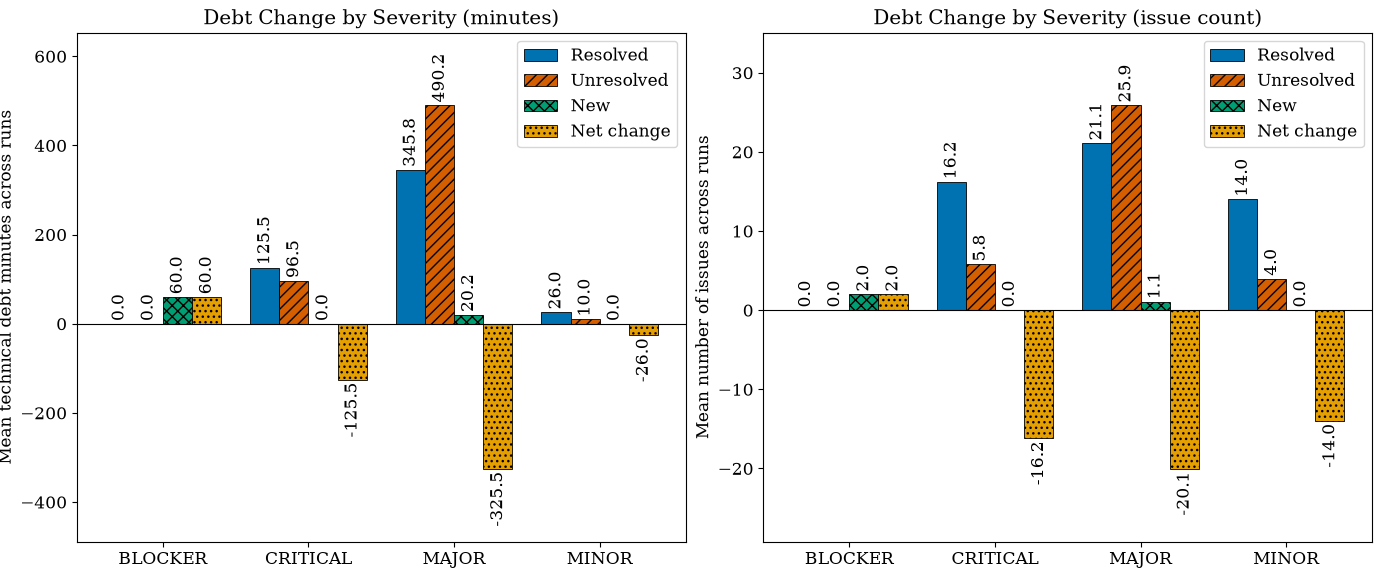

In [14]:
severity_bar_charts(severity_rows)
plt.show()


## Debt Change - AI Agent

In [ ]:
AGENT_RUNS_GLOB = "src/results/active/agent/run_*/sonarqube_issues.json"

TARGETED_ISSUES = {
    "OpenConext/EngineBlock/Logger/Formatter/AdditionalInfoFormatter.php": [46],
    "OpenConext/EngineBlock/Metadata/Entity/Assembler/PushMetadataAssembler.php": [362, 445],
    "OpenConext/EngineBlock/Metadata/Entity/ServiceProvider.php": [100],
    "OpenConext/EngineBlock/Metadata/MetadataRepository/DoctrineMetadataPushRepository.php": [79, 129],
    "OpenConext/EngineBlock/Metadata/MetadataRepository/DoctrineMetadataRepository.php": [186],
    "OpenConext/EngineBlock/Metadata/X509/X509CertificateFactory.php": [41, 47],
    "OpenConext/EngineBlockFunctionalTestingBundle/Features/Context/MinkContext.php": [282],
    "OpenConext/EngineBlockFunctionalTestingBundle/Fixtures/ServiceRegistryFixture.php": [88],
    "OpenConext/EngineBlockFunctionalTestingBundle/Mock/AbstractMockEntityRole.php": [138],
}
targeted_locations = {(f"EngineBlock:{path}", line) for path, lines in TARGETED_ISSUES.items() for line in lines}

base_issues_targeted = filter_issues(base_issues_all, targeted_locations, "include")
print(f"Base issues: {len(base_issues_all)} total, "
      f"{len(base_issues_targeted)} targeted for comparison.")

agent_run_paths = sorted(glob.glob(AGENT_RUNS_GLOB))
if not agent_run_paths:
    raise FileNotFoundError(f"No run files matched: {AGENT_RUNS_GLOB}")

target_overall_rows, target_severity_rows = per_run_debt(base_issues_all, agent_run_paths, targeted_locations, "include")


Base issues: 179 total, 12 targeted for comparison.


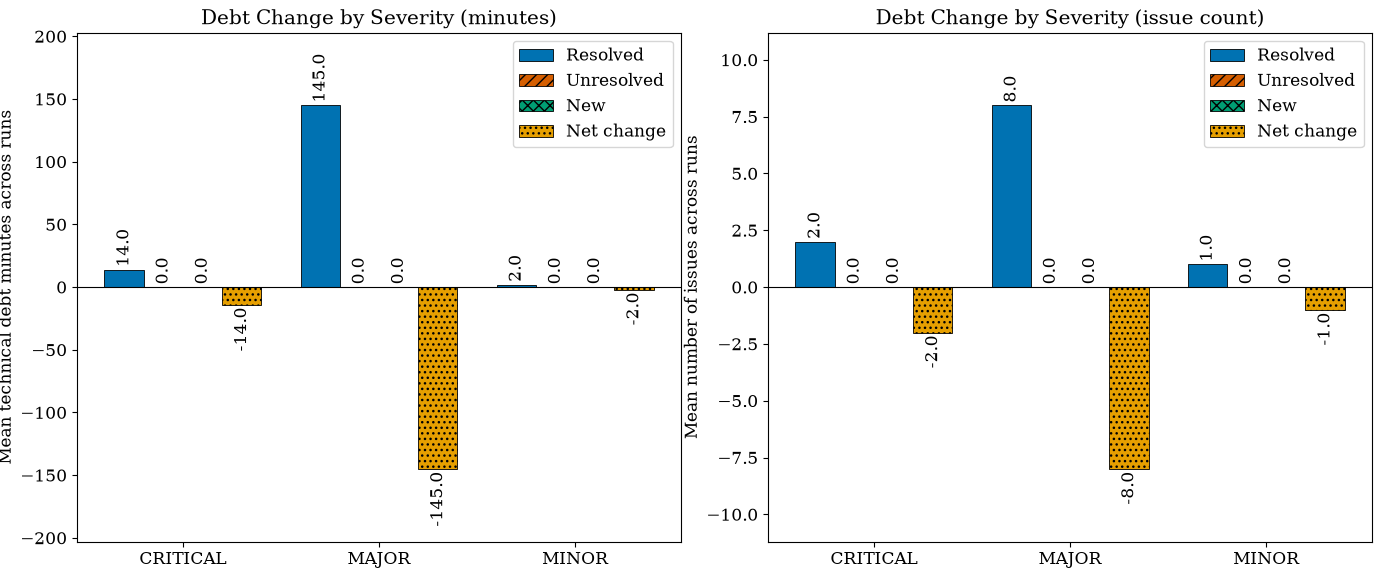

In [16]:
severity_bar_charts(target_severity_rows)
plt.show()
